# Hyper-Tree Examples

This notebook demonstrates how to use the Hyper-Tree models using the Air Passengers dataset.

In [30]:
import pandas as pd
import torch
from hypertrees.models import (
    HyperTreeAR,
    HyperTreeETS,
    HyperTreeNetAR,
    HyperTreeSTL
)
from utils import calculate_metrics, plot_forecasts
import matplotlib.pyplot as plt
import shap

## General Parameters

In [31]:
# General Parameters
lag_p=12  # Lag order for AR(p) models
freq='MS'
fcst_h=12
num_iterations=100
num_seasonal_components=1
seed=123
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyper-Tree Parameters
ht_params = {
    'learning_rate': 1e-01,
}

# Parameters for MLP of Hyper-TreeNet-AR
network_params = {
    'learning_rate': 1e-3,             # learning rate for the neural network
    'embedding_dimension': 1,          # embedding dimension for tree-embeddings
    'hidden_dim': 128,                 # hidden dimension for the MLP network
    'dropout': 0.1,                    # dropout rate for the MLP network
    'use_random_projection': True,     # whether to use random projections for the embeddings
    'rp_embed_dim': lag_p,             # dimension of the random projections (if used)
}

## Load and Prepare Data
We'll use the Air Passengers dataset which contains monthly airline passenger numbers from 1949 to 1960.

In [32]:
# The data needs to have the following columns: 'date', 'series_id', 'value'. All other columns are automatically treated as features.
# For the AR-models, you don't have to add lag-values yourself, this happens automatically during training.
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv', parse_dates=['ds'])
df.rename(columns={'unique_id': 'series_id', 'ds': 'date', 'y': 'value'}, inplace=True)

# Add month and quarter as features
df['month'] = df['date'].dt.month
df["quarter"] = df['date'].dt.quarter

# Split into train and test
test = df.tail(fcst_h)
train = df.drop(test.index)

## Train and Forecast

#### Hyper-Tree-AR

In [33]:
# Initialize
ht_ar = HyperTreeAR(
    p=lag_p,        # AR order (use last p months)
    freq=freq,      # Frequency
    fcst_h=fcst_h,  # Forecast h months ahead
)

# Train
ht_ar.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    verbose=-1
)

# Forecast
ht_ar_fcst = ht_ar.forecast(
    test_data=test,
)

#### Hyper-Tree-ETS

In [34]:
# Initialize
ht_ets = HyperTreeETS(
    ets_type="triple",
    seasonality_feature="month",
    season_length=12,
    freq=freq,
    fcst_h=fcst_h
)

# Train
ht_ets.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    verbose=-1
)

# Forecast
ht_ets_fcst = ht_ets.forecast(
    test_data=test,
)

#### Hyper-TreeNet-AR

In [35]:
# Initialize
htnet_ar = HyperTreeNetAR(
    p=lag_p,
    freq=freq,
    fcst_h=fcst_h,
    device=device
    )

# Train
htnet_ar.train(
    lgb_params=ht_params,
    network_params=network_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    verbose=-1
)

# Forecast
htnet_ar_fcst = htnet_ar.forecast(
    test_data=test,
)

#### Hyper-Tree-STL

For conformal prediction intervals with the other models, see the dedicated `Forecast Intervals.ipynb` example. `HyperTreeSTL` is designed for decomposition and currently does not support them.

In [36]:
# Initialize
ht_stl = HyperTreeSTL(
    period=12,
    num_seasonal_components=num_seasonal_components,
    freq=freq,
    fcst_h=fcst_h,
)

# Add time feature
df_stl = df.copy()
df_stl['time'] = df_stl.groupby("series_id").cumcount() + 1
test_stl = df_stl.tail(fcst_h)
train_stl = df_stl.drop(test_stl.index)

# Train
ht_stl.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train_stl,
    seed=seed,
    verbose=-1
)

# Forecast
ht_stl_fcst = ht_stl.forecast(
    test_data=test_stl,
)

## Plot Results

Let's plot the data and our forecasts.

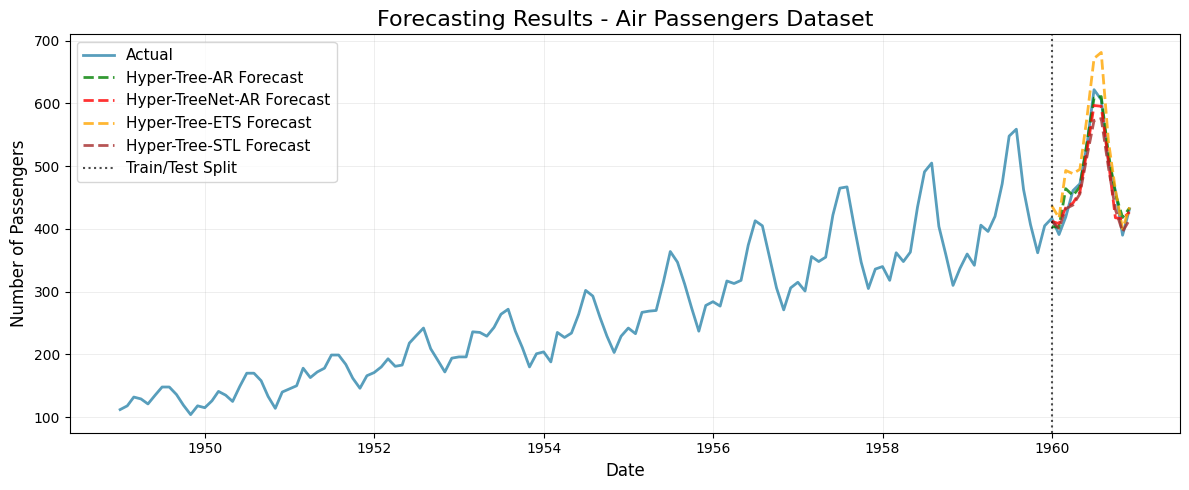

In [37]:
datasets = [
    (df, 'date', 'value', 'Actual', '#2E86AB', '-'),
    (ht_ar_fcst, 'date', 'fcst', 'Hyper-Tree-AR Forecast', 'green', '--'),
    (htnet_ar_fcst, 'date', 'fcst', 'Hyper-TreeNet-AR Forecast', 'red', '--'),
    (ht_ets_fcst, 'date', 'fcst', 'Hyper-Tree-ETS Forecast', 'orange', '--'),
    (ht_stl_fcst, 'date', 'fcst', 'Hyper-Tree-STL Forecast', 'brown', '--'),
    ]

plot_forecasts(
    datasets,
    split_date=test['date'].min(),
    title='Forecasting Results - Air Passengers Dataset',
    ylabel='Number of Passengers',
)

## Evaluate Forecast Accuracy

Let's calculate some basic accuracy metrics to evaluate our forecasts.

In [38]:
fcsts_df = pd.concat(
    [
        ht_ar_fcst,
        ht_ets_fcst,
        htnet_ar_fcst,
        ht_stl_fcst
    ], axis=0).merge(
    test[["date", "value"]],
    on=["date"],
    how="inner"
)

fcsts_df.groupby("model").apply(calculate_metrics).round(3)

,MAE,MAPE,sMAPE,WAPE,RMSE
model,,,,,
Hyper-Tree-AR(12),12.626,2.862,2.797,2.652,17.382
Hyper-Tree-ETS(triple),32.157,6.536,6.233,6.753,39.869
Hyper-Tree-STL(period=12),18.945,3.785,3.862,3.979,22.477
Hyper-TreeNet-AR(12),15.839,3.428,3.457,3.326,19.424


## Inspect Time-Varying Coefficients

One interesting feature of Hyper-Trees is that we can examine the forecasted target-model coefficients, which vary over time based on the features. We use the Hyper-Tree-AR model for this example.

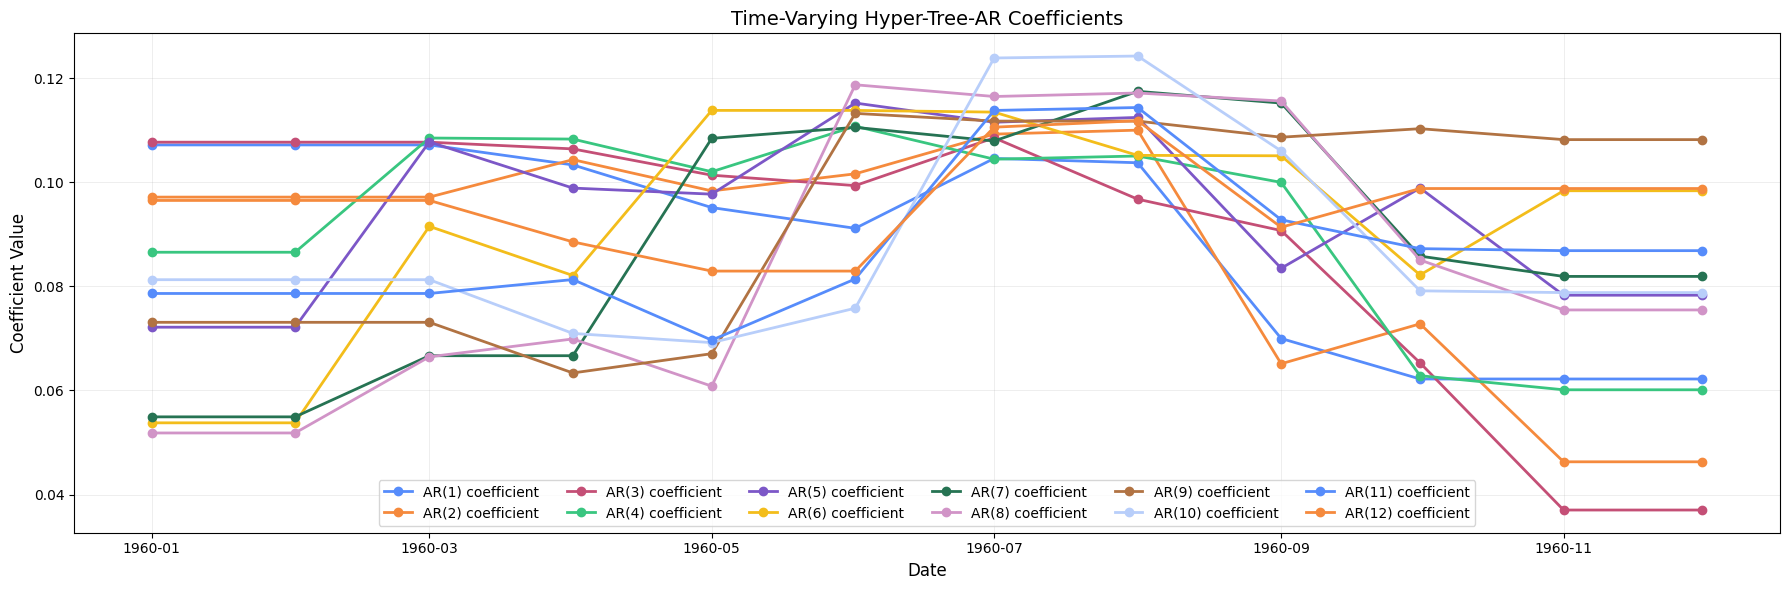

In [39]:
# Get AR coefficients for the forecast period
ar_params = ht_ar.forecast(
    test_data=test,
    type="parameters"
)

# Plot the AR coefficients over time
plt.figure(figsize=(18, 6))
for i in range(1, ht_ar.p + 1):
    plt.plot(ar_params['date'], ar_params[f'AR({i})'], 
             marker='o', linewidth=2, label=f'AR({i}) coefficient')
plt.title('Time-Varying Hyper-Tree-AR Coefficients', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.legend(ncol=6, loc='lower center', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## SHAP Analysis for Parameter Interpretability

Let's use SHAP values to understand which features contribute to the forecasted AR coefficients. We use the Hyper-Tree-AR model for this analysis.

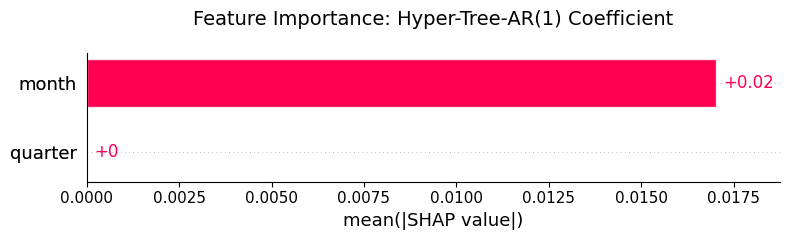

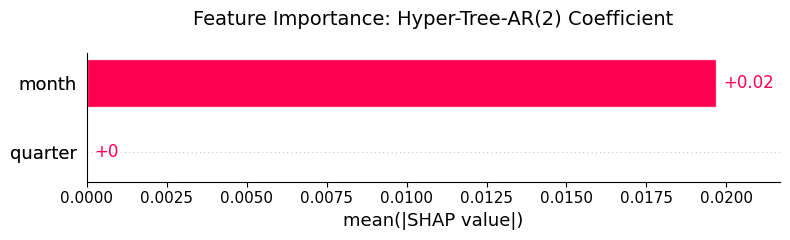

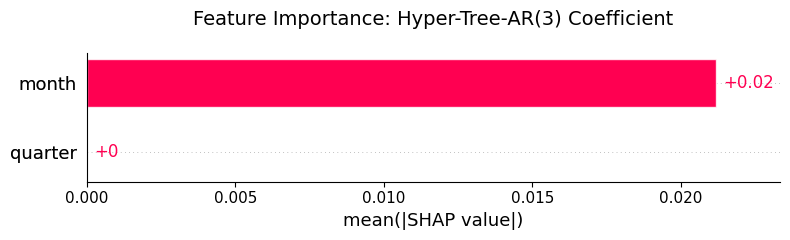

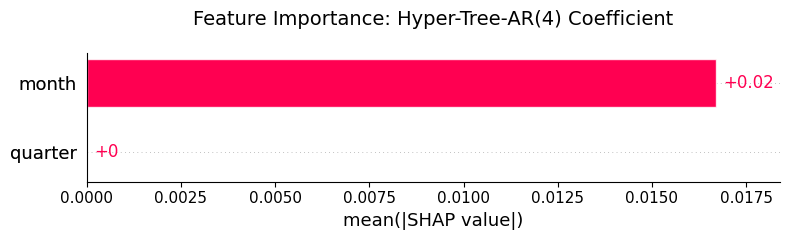

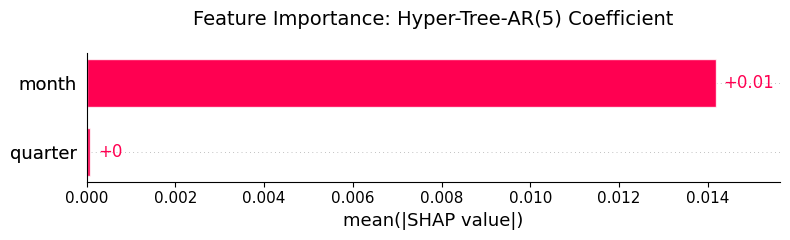

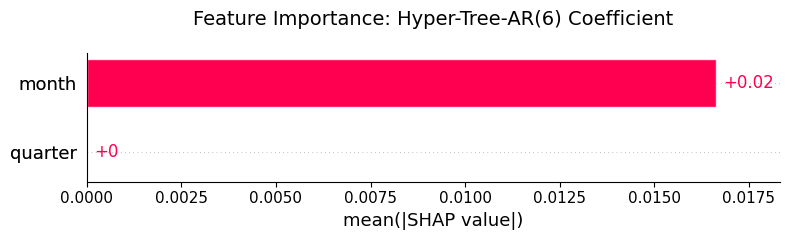

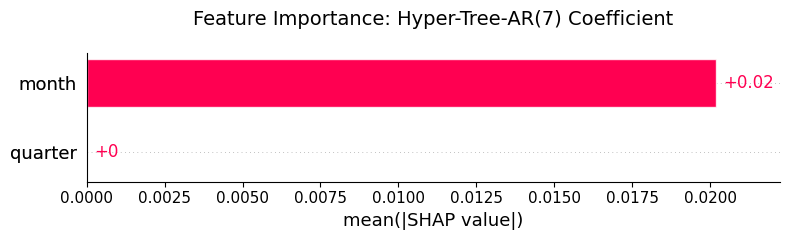

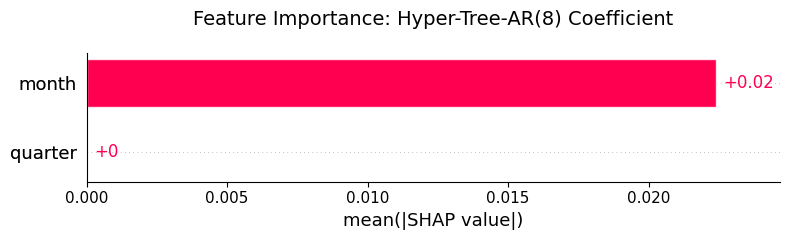

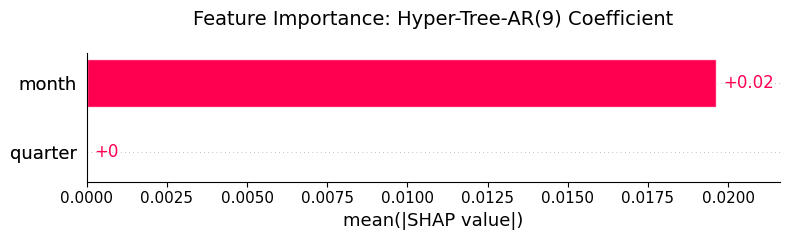

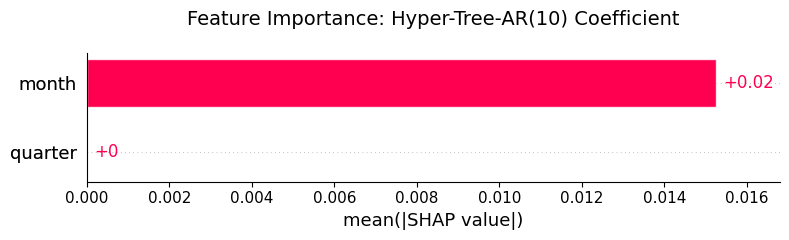

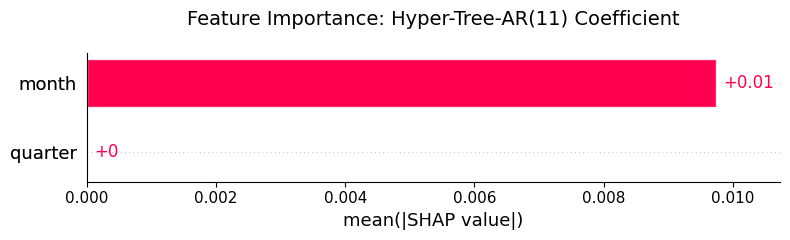

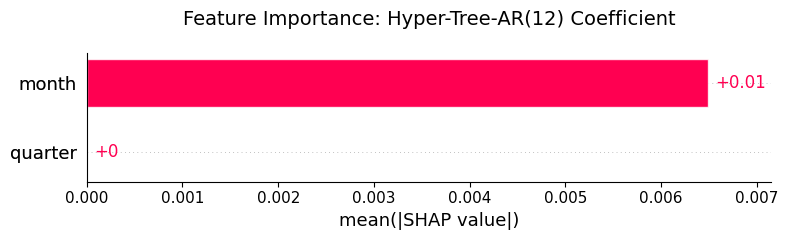

In [40]:
# Select features for SHAP analysis
features = ['month', 'quarter']

# Get the feature data for the test period
shap_features = df[features]

# Get LightGBM model
lgb_model = ht_ar.model

# Create SHAP explainer
shap.initjs()
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(shap_features) # Returns a shap_values object of shape (fcst_h, num_features, ar-coeffs)

# Plot SHAP feature importance plots for AR-Coefficients
for i in range(ht_ar.p):
    plt.figure(figsize=(10, 8))
    shap.plots.bar(shap_values[:, :, i], show=False)
    plt.title(f'Feature Importance: Hyper-Tree-AR({i+1}) Coefficient', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Inspect Tree Embeddings

We can also visualize the learned tree embeddings of the Hyper-TreeNet-AR model to understand what patterns they capture.

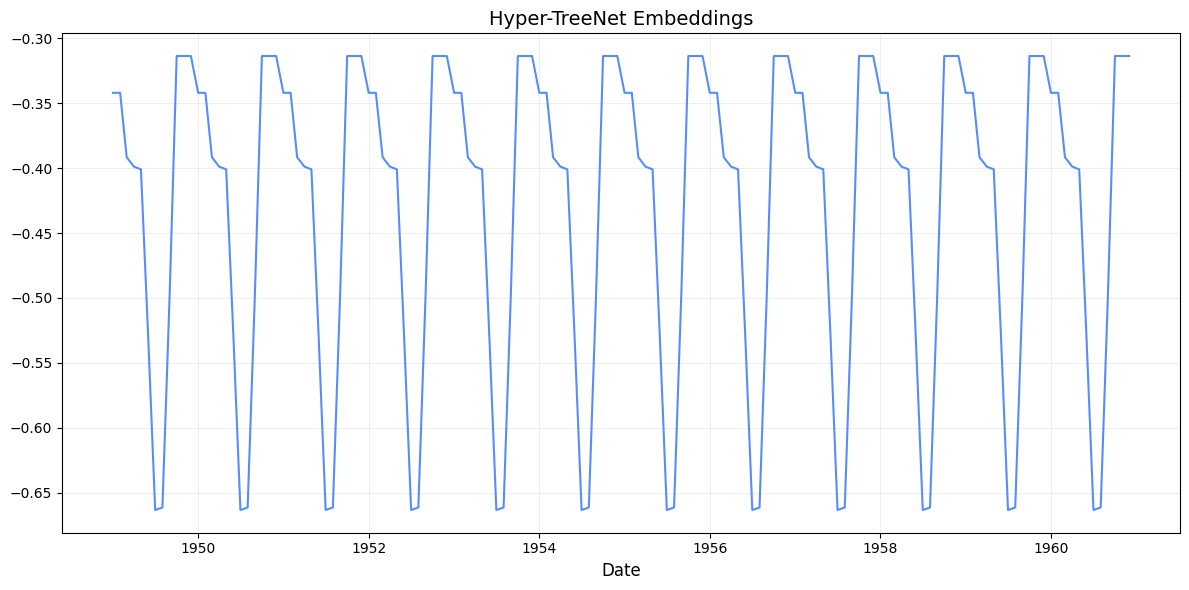

In [41]:
htnet_embeds = htnet_ar.forecast(
    test_data=df,
    type="tree_embeddings"
)

# Plot the tree embeddings over time
plt.figure(figsize=(12, 6))
plt.plot(htnet_embeds['date'], htnet_embeds['tree_embedding_1'])
plt.title('Hyper-TreeNet Embeddings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()